In [8]:
# # old version langgraph with prebuilt ToolNode implementation
# from typing import TypedDict, Annotated
# from langgraph.graph import add_messages, StateGraph, END
# from langchain_groq import ChatGroq
# from langchain_core.messages import AIMessage, HumanMessage
# from dotenv import load_dotenv
# from langchain_community.tools.tavily_search import TavilySearchResults
# from langgraph.prebuilt import ToolNode

# load_dotenv()

# class ChildState(TypedDict):
#     messages: Annotated[list, add_messages]

# search_tool = TavilySearchResults(max_results=2)
# tools = [search_tool]

# llm = ChatGroq(model="llama-3.1-8b-instant")

# llm_with_tools = llm.bind_tools(tools=tools)

# def agent(state: ChildState):
#     return {
#         "messages": [llm_with_tools.invoke(state["messages"])], 
#     }

# def tools_router(state: ChildState):
#     last_message = state["messages"][-1]

#     if(hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0):
#         return "tool_node"
#     else: 
#         return END
    

# tool_node = ToolNode(tools=tools)

# subgraph = StateGraph(ChildState)

# subgraph.add_node("agent", agent)
# subgraph.add_node("tool_node", tool_node)
# subgraph.set_entry_point("agent")

# subgraph.add_conditional_edges("agent", tools_router)
# subgraph.add_edge("tool_node", "agent")

# search_app = subgraph.compile()

In [ ]:

#New version langgraph with manual ToolNode implementation
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, END, add_messages
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage, HumanMessage
from langchain_community.tools.tavily_search import TavilySearchResults
from dotenv import load_dotenv

load_dotenv()

# -----------------------------
# State Definition
# -----------------------------

class ChildState(TypedDict):
    messages: Annotated[list, add_messages]


# -----------------------------
# Tools
# -----------------------------

search_tool = TavilySearchResults(max_results=2)
tools = [search_tool]


# -----------------------------
# LLM with Tool Calling
# -----------------------------

llm = ChatGroq(model="llama-3.1-8b-instant")
llm_with_tools = llm.bind_tools(tools)


# -----------------------------
# Agent Node (LLM)
# -----------------------------

def agent(state: ChildState):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


# -----------------------------
# Tool Node (Manual replacement for ToolNode)
# -----------------------------

def tool_node(state: ChildState):
    last_msg = state["messages"][-1]

    if not hasattr(last_msg, "tool_calls") or not last_msg.tool_calls:
        return {"messages": []}

    results = []
    for call in last_msg.tool_calls:
        name = call["name"]
        args = call["args"]

        tool = next(t for t in tools if t.name == name)
        output = tool.invoke(args)

        results.append(AIMessage(content=str(output), name=name))

    return {"messages": results}


# -----------------------------
# Router Function
# -----------------------------

def tools_router(state: ChildState):
    last = state["messages"][-1]

    if hasattr(last, "tool_calls") and last.tool_calls:
        return "tool_node"
    return END


# -----------------------------
# Build Graph
# -----------------------------

graph = StateGraph(ChildState)

graph.add_node("agent", agent)
graph.add_node("tool_node", tool_node)

graph.set_entry_point("agent")

graph.add_conditional_edges("agent", tools_router)
graph.add_edge("tool_node", "agent")

search_app = graph.compile()


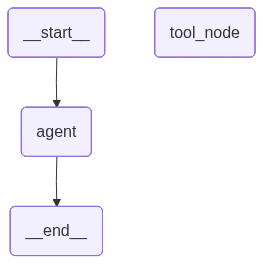

In [10]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        search_app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API
        )
    )
)

In [11]:
search_app.invoke({"messages": [HumanMessage(content="How is the weather in Chennai?")]})

{'messages': [HumanMessage(content='How is the weather in Chennai?', additional_kwargs={}, response_metadata={}, id='36eb81b9-9cbd-48f4-a421-d7ad1fe89186'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'y3yhcf0av', 'function': {'arguments': '{"query":"Chennai weather"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 285, 'total_tokens': 305, 'completion_time': 0.036317011, 'prompt_time': 0.015969204, 'queue_time': 0.049145595, 'total_time': 0.052286215}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--7e29da5c-f57f-4b4c-b794-decf8216d5a1-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Chennai weather'}, 'id': 'y3yhcf0av', 'type': 'tool_call'}], usage_metadata={'input_tokens': 285, 'output_tokens': 20, 'tot

Case 1: Shared Schema (Direct Embedding)

In [12]:
from typing import TypedDict, Annotated
from langgraph.graph import add_messages, StateGraph, START, END
from langchain_core.messages import HumanMessage

# Define parent graph with the same schema
class ParentState(TypedDict):
    messages: Annotated[list, add_messages]

# Create parent graph
parent_graph = StateGraph(ParentState)

# Add the subgraph as a node
parent_graph.add_node("search_agent", search_app)

# Connect the flow
parent_graph.add_edge(START, "search_agent")
parent_graph.add_edge("search_agent", END)

# Compile parent graph
parent_app = parent_graph.compile()

# Run the parent graph
result = parent_app.invoke({"messages": [HumanMessage(content="How is the weather in Chennai?")]})
result

{'messages': [HumanMessage(content='How is the weather in Chennai?', additional_kwargs={}, response_metadata={}, id='0905aff8-256a-48b1-a48b-d1edd5b63837'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ay67rgsh1', 'function': {'arguments': '{"query":"Chennai weather"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 285, 'total_tokens': 305, 'completion_time': 0.0386893, 'prompt_time': 0.015666825, 'queue_time': 0.054911005, 'total_time': 0.054356125}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_1151d4f23c', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--36499fdc-8644-4011-8722-5486026d153c-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Chennai weather'}, 'id': 'ay67rgsh1', 'type': 'tool_call'}], usage_metadata={'input_tokens': 285, 'output_tokens': 20, 'total

Case 2: Different Schema (Invoke with Transformation)

In [14]:
from typing import TypedDict, Annotated, Dict
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage

# Define parent graph with different schema
class QueryState(TypedDict):
    query: str
    response: str

# Function to invoke subgraph
def search_agent(state: QueryState) -> Dict:
    # Transform from parent schema to subgraph schema
    subgraph_input = {
        "messages": [HumanMessage(content=state["query"])]
    }
    
    # Invoke the subgraph
    subgraph_result = search_app.invoke(subgraph_input)
    
    # Transform response back to parent schema
    assistant_message = subgraph_result["messages"][-1]
    return {"response": assistant_message.content}

# Create parent graph
parent_graph = StateGraph(QueryState)

# Add transformation node that invokes subgraph
parent_graph.add_node("search_agent", search_agent)

# Connect the flow
parent_graph.add_edge(START, "search_agent")
parent_graph.add_edge("search_agent", END)

# Compile parent graph
parent_app = parent_graph.compile()

# Run the parent graph
result = parent_app.invoke({"query": "How is the weather in Chennai?", "response": ""})
print(result)

{'query': 'How is the weather in Chennai?', 'response': ''}
